# 03 — Baseline modeling and evaluation

This notebook evaluates whether the morphology features extracted in Notebook 02 contain useful signal for binary ECG-only classification of Brugada-positive versus non-Brugada records. The project target is kept fixed: `brugada = 0` is treated as non-Brugada, while `brugada > 0` is treated as Brugada positive.

The analysis is intentionally framed as a first baseline rather than an optimized model search. Two feature sets are compared: right-precordial morphology from V1–V2 and the same representation extended to V1–V3. Models are evaluated with 5-fold stratified cross-validation using balanced accuracy as the main metric, with recall, precision, F1 and ROC-AUC reported to characterize the trade-off between false negatives and false positives.

## 1. Imports and configuration

This section defines the modeling environment, input feature tables and output paths. Processed ECG features are read from `data/processed/`, while model-evaluation artifacts are saved to `results/`.

In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import wfdb

from sklearn.model_selection import StratifiedKFold, cross_validate, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.svm import LinearSVC, SVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    make_scorer,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

RANDOM_STATE = 42
N_JOBS = -1

RAW_DATA_DIR = r"..\data\raw\brugada-huca-1.0.0"
DATA_DIR = r"..\data\processed"
RESULTS_DIR = r"..\results"

os.makedirs(RESULTS_DIR, exist_ok=True)

RAW_RECORDS_DIR = os.path.join(RAW_DATA_DIR, "files")

FEATURES_PATH = os.path.join(DATA_DIR, "ecg_morphology_features.csv")
QC_PATH = os.path.join(DATA_DIR, "ecg_morphology_feature_qc.csv")

BASELINE_RESULTS_PATH = os.path.join(RESULTS_DIR, "baseline_cv_results.csv")
FEATURE_SET_COMPARISON_PATH = os.path.join(RESULTS_DIR, "baseline_feature_set_comparison.csv")
ERROR_ANALYSIS_PATH = os.path.join(RESULTS_DIR, "baseline_oof_error_analysis.csv")
ERROR_RECORDS_PATH = os.path.join(RESULTS_DIR, "oof_misclassified_records.csv")

## 2. Load data

The morphology feature table is the modeling input. The QC table is loaded only for inspection and traceability; QC variables are not used as predictors in this baseline.

In [2]:
features = pd.read_csv(FEATURES_PATH)
qc = pd.read_csv(QC_PATH)

print("Features shape:", features.shape)
print("QC shape:", qc.shape)


Features shape: (361, 109)
QC shape: (363, 68)


In [3]:
features.head()

,patient_id,brugada,brugada_syndrome,basal_pattern,sudden_death,fs,record_base,r_detection_lead,morphology_highpass_cutoff_hz,morphology_lowpass_cutoff_hz,...,v3_st_slope_j040_j120_mV_per_s,v3_coved_proxy_j040_j120_mV,v3_true_st_max_j000_j120_mV,v3_st_area_j000_j120_mV_s,v3_st_max_time_j000_j120_ms,v3_st_curv_j000_j120_mV,v3_st_peak_to_late_drop_j000_j120_mV,v3_t_curv_j120_r320_mV,v3_t_min_j120_r320_mV,v3_coved_shape_index
0,188981,1,1,1,0,100.0,../data/raw/brugada-huca-1.0.0\files\188981\18...,II,NaN,40,...,0.684728,-0.054778,0.178614,0.016023,120.0,-0.017130,0.000000,0.173176,0.149420,0.178614
1,251972,0,0,0,0,100.0,../data/raw/brugada-huca-1.0.0\files\251972\25...,II,NaN,40,...,3.332361,-0.266589,0.405244,0.022457,120.0,-0.010585,0.000000,0.226272,0.073189,0.405244
2,265715,0,0,0,0,100.0,../data/raw/brugada-huca-1.0.0\files\265715\26...,II,NaN,40,...,1.465296,-0.117224,0.070007,-0.002898,120.0,-0.003539,0.000000,0.308683,-0.051861,0.121868
3,267628,0,0,0,0,100.0,../data/raw/brugada-huca-1.0.0\files\267628\26...,II,NaN,40,...,1.432853,-0.114628,0.027288,-0.007477,120.0,0.005207,0.000000,0.352449,-0.010030,0.037318
4,286830,0,0,0,0,100.0,../data/raw/brugada-huca-1.0.0\files\286830\28...,II,NaN,40,...,0.894936,-0.071595,0.066527,0.002166,110.0,-0.006952,-0.014401,0.111423,-0.017679,0.084207


In [4]:
qc.head()

,metadata_index,patient_id,status,error,fs,record_base,r_detection_lead,morphology_highpass_cutoff_hz,morphology_lowpass_cutoff_hz,baseline_reference_window_start_s,...,j_n_leads_used,j_leads_used,t_curvature_left_offset_from_j_s,t_curvature_right_time_from_r_s,high_hr_flag,short_cycle_flag,low_beat_count_flag,high_overlap_flag,jpoint_unreliable_flag,jpoint_timing_flag
0,0,188981,ok,NaN,100.0,../data/raw/brugada-huca-1.0.0\files\188981\18...,II,NaN,40,-0.2,...,3.0,"V1,V2,V3",NaN,NaN,False,False,False,False,False,False
1,1,251972,ok,NaN,100.0,../data/raw/brugada-huca-1.0.0\files\251972\25...,II,NaN,40,-0.2,...,3.0,"V1,V2,V3",NaN,NaN,False,False,False,False,False,False
2,2,265715,ok,NaN,100.0,../data/raw/brugada-huca-1.0.0\files\265715\26...,II,NaN,40,-0.2,...,3.0,"V1,V2,V3",NaN,NaN,False,False,False,False,False,False
3,3,267628,ok,NaN,100.0,../data/raw/brugada-huca-1.0.0\files\267628\26...,II,NaN,40,-0.2,...,3.0,"V1,V2,V3",NaN,NaN,False,False,False,False,True,True
4,4,267630,failed,Fewer than 3 valid beats detected.,100.0,../data/raw/brugada-huca-1.0.0\files\267630\26...,II,NaN,40,-0.2,...,NaN,NaN,0.12,0.32,False,True,True,True,False,False


## 3. Binary target

The binary target follows the project definition established in Notebook 01: all records with `brugada > 0` are treated as Brugada positive, including flecainide-confirmed positive cases. This keeps the classification task aligned with the intended ECG-only screening question.

In [5]:
features["brugada_syndrome"] = (features["brugada"] > 0).astype(int)

target_counts = (
    features["brugada_syndrome"]
    .value_counts()
    .sort_index()
    .rename(index={0: "non-Brugada", 1: "Brugada positive"})
)

display(target_counts)

print(f"Positive class proportion: {features['brugada_syndrome'].mean():.3f}")
print(f"Negative class proportion: {1 - features['brugada_syndrome'].mean():.3f}")

brugada_syndrome
non-Brugada         287
Brugada positive     74
Name: count, dtype: int64

Positive class proportion: 0.205
Negative class proportion: 0.795


## 4. Feature sets

The baseline uses 16 morphology features per lead, derived from the representative median beat and focused on QRS, ST-segment and T-wave morphology. Two predefined feature sets are evaluated: V1–V2, which captures the core right-precordial leads, and V1–V3, which adds adjacent right-precordial context without expanding to the full 12-lead ECG.

In [6]:
BASE_MORPHOLOGY_FEATURES = [
    "r_amp_mV",
    "s_amp_mV",
    "st_j000_mV",
    "st_j040_mV",
    "st_j080_mV",
    "st_j120_mV",
    "true_st_max_j000_j120_mV",
    "st_max_time_j000_j120_ms",
    "st_peak_to_late_drop_j000_j120_mV",
    "st_slope_j040_j120_mV_per_s",
    "st_area_j000_j120_mV_s",
    "st_curv_j000_j120_mV",
    "coved_proxy_j040_j120_mV",
    "coved_shape_index",
    "t_curv_j120_r320_mV",
    "t_min_j120_r320_mV",
]


In [7]:
def make_lead_feature_columns(leads, base_features):
    return [
        f"{lead.lower()}_{feature}"
        for lead in leads
        for feature in base_features
    ]

In [8]:
v1_v2_features = make_lead_feature_columns(
    leads=["V1", "V2"],
    base_features=BASE_MORPHOLOGY_FEATURES,
)

v1_v3_features = make_lead_feature_columns(
    leads=["V1", "V2", "V3"],
    base_features=BASE_MORPHOLOGY_FEATURES,
)

feature_sets = {
    "V1-V2": v1_v2_features,
    "V1-V3": v1_v3_features,
}

all_model_features = [
    feature
    for feature_columns in feature_sets.values()
    for feature in feature_columns
]

all_model_features = sorted(set(all_model_features))

required_columns = [
    "patient_id",
    "brugada",
    "brugada_syndrome",
    "basal_pattern",
] + all_model_features

missing_columns = [col for col in required_columns if col not in features.columns]
assert not missing_columns, f"Missing expected columns: {missing_columns}"

for name, columns in feature_sets.items():
    print(f"{name} features: {len(columns)}")

assert len(feature_sets["V1-V2"]) == 32
assert len(feature_sets["V1-V3"]) == 48


V1-V2 features: 32
V1-V3 features: 48


The expected dimensions are 32 features for V1–V2 and 48 features for V1–V3. These counts are checked before modeling to ensure that the intended feature sets are being evaluated.

## 5. Modeling dataset

The same records are used for both feature sets. Since Notebook 01 and Notebook 02 already established the expected dataset structure, this section keeps only essential checks for missing or non-finite modeling values.

In [9]:
model_data = features.dropna(
    subset=all_model_features + ["brugada_syndrome"]
).copy()

assert len(model_data) == len(features), "Unexpected missing values in modeling columns."
assert np.isfinite(model_data[all_model_features].to_numpy()).all(), "Unexpected infinite values in modeling columns."

print("Records:", len(model_data))
print("Positive records:", int(model_data["brugada_syndrome"].sum()))
print("Negative records:", int((model_data["brugada_syndrome"] == 0).sum()))


Records: 361
Positive records: 74
Negative records: 287


In [10]:
model_data["brugada_syndrome"].value_counts().sort_index()


brugada_syndrome
0    287
1     74
Name: count, dtype: int64

## 6. Baseline models

The candidate model set gives methodological priority to simple and relatively low-complexity classifiers, especially linear models. This is intentional: the dataset is small, the positive class is limited, and the ECG morphology features are handcrafted and partly correlated. In this setting, simpler models are often preferable because they are less prone to overfitting, easier to interpret, and provide a stronger baseline for assessing whether the extracted ECG features carry useful diagnostic signal.

Nonlinear models are still included as comparators. Their role is to check whether additional flexibility improves validation performance without producing a large train-validation gap. If a nonlinear model performs better only on the training folds, or only marginally better in validation, the simpler model should remain the more credible baseline.

In [11]:
models = {
    "Dummy Classifier": DummyClassifier(strategy="most_frequent"),

    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            class_weight="balanced",
            max_iter=5000,
            solver="liblinear",
            random_state=RANDOM_STATE,
        )),
    ]),

    "Ridge Classifier": Pipeline([
        ("scaler", StandardScaler()),
        ("model", RidgeClassifier(
            class_weight="balanced",
        )),
    ]),

    "Linear SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearSVC(
            class_weight="balanced",
            max_iter=20000,
            dual=False,
            random_state=RANDOM_STATE,
        )),
    ]),

    "LDA Shrinkage": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearDiscriminantAnalysis(
            solver="lsqr",
            shrinkage="auto",
        )),
    ]),

    "Gaussian NB": GaussianNB(),

    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(
            n_neighbors=7,
        )),
    ]),

    "RBF SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(
            kernel="rbf",
            class_weight="balanced",
            random_state=RANDOM_STATE,
        )),
    ]),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),

    "Extra Trees": ExtraTreesClassifier(
        n_estimators=300,
        class_weight="balanced",
        random_state=RANDOM_STATE,
    ),

    "Gradient Boosting": GradientBoostingClassifier(
        random_state=RANDOM_STATE,
    ),
}


## 7. Cross-validation and metrics

Five-fold stratified cross-validation is used to preserve the class ratio in each fold and avoid relying on a single small hold-out split. Balanced accuracy is the primary metric because the dataset is imbalanced; recall and precision are inspected separately to understand the false-negative and false-positive behavior.

In [12]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

# `scoring` defines the metrics computed by cross-validation.
#
# Some metrics can be passed as scikit-learn scorer names, such as:
# "balanced_accuracy" and "roc_auc".
#
# For precision, recall and F1, `make_scorer()` is used to adapt metric
# functions such as:
#
#     precision_score(y_true, y_pred, zero_division=0)
#
# to the scorer interface expected by `cross_validate()`:
#
#     scorer(model, X_validation, y_validation)
#
# Conceptually, this is equivalent to:
#
#     def scorer(model, X_validation, y_validation):
#         y_pred = model.predict(X_validation)
#         return precision_score(
#             y_validation,
#             y_pred,
#             zero_division=0,
#         )
#
# The same logic applies to recall_score and f1_score. The argument
# zero_division=0 avoids undefined metric warnings when no positive
# predictions are made in a validation fold.
scoring = {
    "balanced_accuracy": "balanced_accuracy",
    "f1": make_scorer(f1_score, zero_division=0),
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "roc_auc": "roc_auc",
}

In [13]:
models.items()

dict_items([('Dummy Classifier', DummyClassifier(strategy='most_frequent')), ('Logistic Regression', Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=5000,
                                    random_state=42, solver='liblinear'))])), ('Ridge Classifier', Pipeline(steps=[('scaler', StandardScaler()),
                ('model', RidgeClassifier(class_weight='balanced'))])), ('Linear SVM', Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 LinearSVC(class_weight='balanced', dual=False, max_iter=20000,
                           random_state=42))])), ('LDA Shrinkage', Pipeline(steps=[('scaler', StandardScaler()),
                ('model',
                 LinearDiscriminantAnalysis(shrinkage='auto', solver='lsqr'))])), ('Gaussian NB', GaussianNB()), ('KNN', Pipeline(steps=[('scaler', StandardScaler()),
                ('model', KNeighborsClassifier(n_neighbors=7)

In [14]:
def evaluate_feature_set(df, feature_set_name, feature_columns, models, cv, scoring):
    """
    Evaluate multiple classification models for a single ECG feature set using cross-validation.

    This function selects the requested feature columns, uses `brugada_syndrome` as the
    binary target, and evaluates each model with the same cross-validation strategy and
    scoring metrics. For each model, it stores the mean and standard deviation of each
    train and validation score across folds.

    Parameters
    ----------
    df : pandas.DataFrame
        Modeling dataset containing the feature columns and the `brugada_syndrome` target.
    feature_set_name : str
        Descriptive name of the feature set being evaluated, for example "V1-V2" or "V1-V3".
    feature_columns : list of str
        Feature column names used as model inputs.
    models : dict
        Dictionary mapping model names to scikit-learn estimators or pipelines.
    cv : cross-validation splitter
        Cross-validation strategy, for example a StratifiedKFold object.
    scoring : dict
        Dictionary mapping metric names to scikit-learn scorers.

    Returns
    -------
    pandas.DataFrame
        One row per model, including dataset counts, number of features, train and
        validation metric summaries, and train-validation gaps for balanced accuracy
        and ROC-AUC.
    """
    
    X = df[feature_columns]
    y = df["brugada_syndrome"]

    rows = []

    for model_name, model in models.items():
        cv_results = cross_validate(
            estimator=model,
            X=X,
            y=y,
            cv=cv,
            scoring=scoring,
            return_train_score=True,
            n_jobs=N_JOBS,
        )

        row = {
            "feature_set": feature_set_name,
            "model": model_name,
            "n_records": len(y),
            "n_positive": y.sum(),
            "n_negative": (y == 0).sum(),
            "n_features": len(feature_columns),
        }

        for metric_name in scoring.keys():
            train_scores = cv_results[f"train_{metric_name}"]
            test_scores = cv_results[f"test_{metric_name}"]

            row[f"train_{metric_name}_mean"] = train_scores.mean()
            row[f"train_{metric_name}_std"] = train_scores.std()
            row[f"test_{metric_name}_mean"] = test_scores.mean()
            row[f"test_{metric_name}_std"] = test_scores.std()

        row["gap_balanced_accuracy"] = (
            row["train_balanced_accuracy_mean"] - row["test_balanced_accuracy_mean"]
        )
        row["gap_roc_auc"] = row["train_roc_auc_mean"] - row["test_roc_auc_mean"]

        rows.append(row)

    return pd.DataFrame(rows)


## 8. Run baseline evaluation

Each model is evaluated on both feature sets with the same cross-validation scheme and metrics. Train scores are also stored to estimate the train/test gap as a simple overfitting diagnostic.

In [15]:
results = pd.concat(
    [
        evaluate_feature_set(
            df=model_data,
            feature_set_name=name,
            feature_columns=columns,
            models=models,
            cv=cv,
            scoring=scoring,
        )
        for name, columns in feature_sets.items()
    ],
    ignore_index=True,
)

results.head()


,feature_set,model,n_records,n_positive,n_negative,n_features,train_balanced_accuracy_mean,train_balanced_accuracy_std,test_balanced_accuracy_mean,test_balanced_accuracy_std,...,train_recall_mean,train_recall_std,test_recall_mean,test_recall_std,train_roc_auc_mean,train_roc_auc_std,test_roc_auc_mean,test_roc_auc_std,gap_balanced_accuracy,gap_roc_auc
0,V1-V2,Dummy Classifier,361,74,287,32,0.500000,0.000000,0.500000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.500000,0.000000,0.500000,0.000000,0.000000,0.000000
1,V1-V2,Logistic Regression,361,74,287,32,0.884779,0.021154,0.848459,0.046403,...,0.881921,0.027353,0.825714,0.107395,0.948296,0.007496,0.906964,0.021026,0.036319,0.041332
2,V1-V2,Ridge Classifier,361,74,287,32,0.882156,0.014063,0.841546,0.040715,...,0.851412,0.019209,0.798095,0.110476,0.946687,0.007459,0.906003,0.038428,0.040610,0.040684
3,V1-V2,Linear SVM,361,74,287,32,0.893806,0.012897,0.840359,0.061123,...,0.888644,0.022096,0.799048,0.151198,0.955643,0.009813,0.900508,0.031211,0.053447,0.055135
4,V1-V2,LDA Shrinkage,361,74,287,32,0.819290,0.017335,0.794301,0.113407,...,0.665593,0.035600,0.620000,0.232475,0.930578,0.008416,0.908756,0.045544,0.024989,0.021821


## 9. Main results

The main comparison uses validation performance, but the results should not be read only by ranking the highest score. This is a small biomedical dataset, so model complexity matters. When two models perform similarly, the simpler one is usually the more reliable baseline, especially if the more complex model shows a larger train-validation gap. For this reason, balanced accuracy and ROC-AUC are used to assess predictive performance, while the train-validation gaps help identify possible overfitting.

In [16]:
model_families = {
    "Logistic Regression": "Linear",
    "Ridge Classifier": "Linear",
    "Linear SVM": "Linear",
    "LDA Shrinkage": "Linear discriminant",
    "Gaussian NB": "Probabilistic",
    "KNN": "Distance-based",
    "RBF SVM": "Kernel nonlinear",
    "Random Forest": "Tree ensemble",
    "Extra Trees": "Tree ensemble",
    "Gradient Boosting": "Tree ensemble",
}

main_cols = [
    "feature_set",
    "model",
    "n_records",
    "n_positive",
    "n_features",
    "test_balanced_accuracy_mean",
    "test_balanced_accuracy_std",
    "test_f1_mean",
    "test_precision_mean",
    "test_recall_mean",
    "test_roc_auc_mean",
    "gap_balanced_accuracy",
    "gap_roc_auc",
]

results_main = results[main_cols].copy()
results_main["model_family"] = results_main["model"].map(model_families).fillna("Other")

results_main = (
    results_main[
        [
            "feature_set",
            "model",
            "model_family",
            "n_records",
            "n_positive",
            "n_features",
            "test_balanced_accuracy_mean",
            "test_balanced_accuracy_std",
            "test_f1_mean",
            "test_precision_mean",
            "test_recall_mean",
            "test_roc_auc_mean",
            "gap_balanced_accuracy",
            "gap_roc_auc",
        ]
    ]
    .sort_values(
        by="test_balanced_accuracy_mean",
        ascending=False,
    )
    .reset_index(drop=True)
)

# Display rounded values only. This does not modify `results_main`, so the
# next cell still uses the full-precision, already sorted results table.
results_main.round(3)


,feature_set,model,model_family,n_records,n_positive,n_features,test_balanced_accuracy_mean,test_balanced_accuracy_std,test_f1_mean,test_precision_mean,test_recall_mean,test_roc_auc_mean,gap_balanced_accuracy,gap_roc_auc
0,V1-V3,Logistic Regression,Linear,361,74,48,0.862,0.048,0.732,0.653,0.839,0.916,0.048,0.047
1,V1-V2,Logistic Regression,Linear,361,74,32,0.848,0.046,0.708,0.628,0.826,0.907,0.036,0.041
2,V1-V3,Linear SVM,Linear,361,74,48,0.845,0.050,0.709,0.635,0.812,0.905,0.069,0.063
3,V1-V2,Ridge Classifier,Linear,361,74,32,0.842,0.041,0.709,0.649,0.798,0.906,0.041,0.041
4,V1-V2,Linear SVM,Linear,361,74,32,0.840,0.061,0.701,0.640,0.799,0.901,0.053,0.055
5,V1-V3,Ridge Classifier,Linear,361,74,48,0.839,0.066,0.705,0.635,0.796,0.918,0.060,0.043
6,V1-V2,RBF SVM,Kernel nonlinear,361,74,32,0.827,0.044,0.718,0.716,0.730,0.893,0.102,0.078
7,V1-V3,LDA Shrinkage,Linear discriminant,361,74,48,0.805,0.096,0.706,0.808,0.649,0.921,0.030,0.024
8,V1-V2,Gradient Boosting,Tree ensemble,361,74,32,0.800,0.067,0.707,0.845,0.635,0.894,0.200,0.106
9,V1-V2,LDA Shrinkage,Linear discriminant,361,74,32,0.794,0.113,0.687,0.832,0.620,0.909,0.025,0.022


In [17]:
# This summary keeps the best-performing candidate within each model family.
# It is descriptive only and does not filter models from the comparison.

best_model_per_family = (results_main.groupby("model_family", sort=False)
    .head(1)
    .reset_index(drop=True)
)

best_model_per_family.round(3)


,feature_set,model,model_family,n_records,n_positive,n_features,test_balanced_accuracy_mean,test_balanced_accuracy_std,test_f1_mean,test_precision_mean,test_recall_mean,test_roc_auc_mean,gap_balanced_accuracy,gap_roc_auc
0,V1-V3,Logistic Regression,Linear,361,74,48,0.862,0.048,0.732,0.653,0.839,0.916,0.048,0.047
1,V1-V2,RBF SVM,Kernel nonlinear,361,74,32,0.827,0.044,0.718,0.716,0.730,0.893,0.102,0.078
2,V1-V3,LDA Shrinkage,Linear discriminant,361,74,48,0.805,0.096,0.706,0.808,0.649,0.921,0.030,0.024
3,V1-V2,Gradient Boosting,Tree ensemble,361,74,32,0.800,0.067,0.707,0.845,0.635,0.894,0.200,0.106
4,V1-V2,Gaussian NB,Probabilistic,361,74,32,0.786,0.049,0.637,0.599,0.702,0.873,0.023,0.020
5,V1-V2,KNN,Distance-based,361,74,32,0.767,0.101,0.659,0.889,0.551,0.853,0.014,0.085
6,V1-V2,Dummy Classifier,Other,361,74,32,0.500,0.000,0.000,0.000,0.000,0.500,0.000,0.000


## 10. V1–V2 vs V1–V3 comparison

This comparison tests whether adding V3 provides useful context beyond V1–V2. The goal is not only to identify the best feature set, but also to check whether the gain from the extra lead is consistent across model families.

In [18]:
comparison_bal_acc = results.pivot(
    index="model",
    columns="feature_set",
    values="test_balanced_accuracy_mean",
)

comparison_bal_acc.columns.name = "feature_set / test_balanced_accuracy_mean"

comparison_bal_acc["delta_V1_V3_minus_V1_V2"] = (
    comparison_bal_acc["V1-V3"] - comparison_bal_acc["V1-V2"]
)

comparison_bal_acc = comparison_bal_acc.sort_values(
    "delta_V1_V3_minus_V1_V2",
    ascending=False,
)

comparison_bal_acc.round(3)


feature_set / test_balanced_accuracy_mean,V1-V2,V1-V3,delta_V1_V3_minus_V1_V2
model,,,
Logistic Regression,0.848,0.862,0.014
LDA Shrinkage,0.794,0.805,0.011
Linear SVM,0.840,0.845,0.005
Random Forest,0.739,0.741,0.002
Dummy Classifier,0.500,0.500,0.000
Ridge Classifier,0.842,0.839,-0.003
Extra Trees,0.754,0.742,-0.012
Gaussian NB,0.786,0.773,-0.013
Gradient Boosting,0.800,0.785,-0.015


In [19]:
comparison_auc = results.pivot(
    index="model",
    columns="feature_set",
    values="test_roc_auc_mean",
)

comparison_auc.columns.name = "feature_set / test_roc_auc_mean"

comparison_auc["delta_V1_V3_minus_V1_V2"] = (
    comparison_auc["V1-V3"] - comparison_auc["V1-V2"]
)

comparison_auc = comparison_auc.sort_values(
    "delta_V1_V3_minus_V1_V2",
    ascending=False,
)

comparison_auc.round(3)


feature_set / test_roc_auc_mean,V1-V2,V1-V3,delta_V1_V3_minus_V1_V2
model,,,
LDA Shrinkage,0.909,0.921,0.013
Ridge Classifier,0.906,0.918,0.012
Logistic Regression,0.907,0.916,0.009
Random Forest,0.877,0.882,0.005
Linear SVM,0.901,0.905,0.004
RBF SVM,0.893,0.893,0.000
Dummy Classifier,0.500,0.500,0.000
Extra Trees,0.892,0.891,-0.001
KNN,0.853,0.851,-0.001


In [20]:
comparison = (
    comparison_bal_acc[["V1-V2", "V1-V3", "delta_V1_V3_minus_V1_V2"]]
    .rename(columns={
        "V1-V2": "balanced_accuracy_V1_V2",
        "V1-V3": "balanced_accuracy_V1_V3",
        "delta_V1_V3_minus_V1_V2": "delta_balanced_accuracy",
    })
    .join(
        comparison_auc[["V1-V2", "V1-V3", "delta_V1_V3_minus_V1_V2"]]
        .rename(columns={
            "V1-V2": "roc_auc_V1_V2",
            "V1-V3": "roc_auc_V1_V3",
            "delta_V1_V3_minus_V1_V2": "delta_roc_auc",
        })
    )
    .reset_index()
)

comparison.round(3)


,model,balanced_accuracy_V1_V2,balanced_accuracy_V1_V3,delta_balanced_accuracy,roc_auc_V1_V2,roc_auc_V1_V3,delta_roc_auc
0,Logistic Regression,0.848,0.862,0.014,0.907,0.916,0.009
1,LDA Shrinkage,0.794,0.805,0.011,0.909,0.921,0.013
2,Linear SVM,0.840,0.845,0.005,0.901,0.905,0.004
3,Random Forest,0.739,0.741,0.002,0.877,0.882,0.005
4,Dummy Classifier,0.500,0.500,0.000,0.500,0.500,0.000
5,Ridge Classifier,0.842,0.839,-0.003,0.906,0.918,0.012
6,Extra Trees,0.754,0.742,-0.012,0.892,0.891,-0.001
7,Gaussian NB,0.786,0.773,-0.013,0.873,0.854,-0.019
8,Gradient Boosting,0.800,0.785,-0.015,0.894,0.883,-0.012
9,RBF SVM,0.827,0.785,-0.042,0.893,0.893,0.000


## 11. Simple visualization

The plot summarizes cross-validated balanced accuracy for each model and feature set. It is used as a quick visual check of model ranking and of the effect of adding V3.

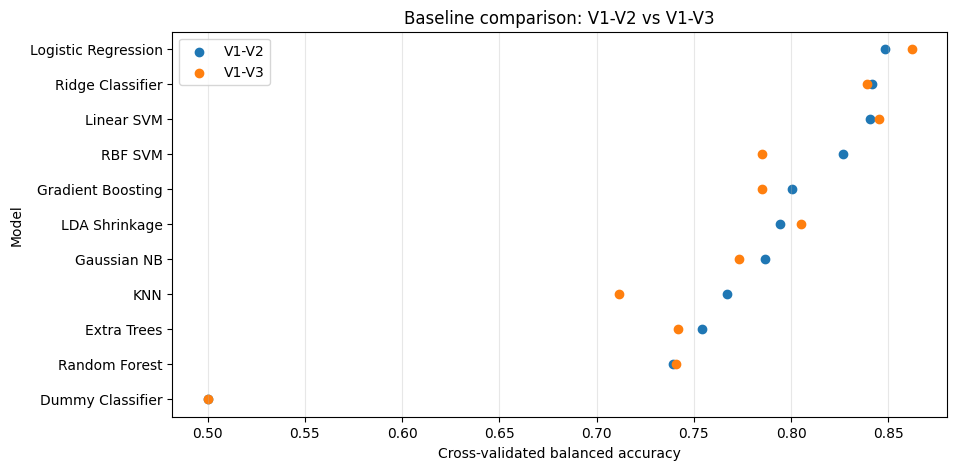

In [21]:
plot_data = results.copy()

plt.figure(figsize=(10, 5))

for feature_set in ["V1-V2", "V1-V3"]:
    subset = plot_data[plot_data["feature_set"] == feature_set]
    subset = subset.sort_values("test_balanced_accuracy_mean", ascending=True)
    plt.scatter(
        subset["test_balanced_accuracy_mean"],
        subset["model"],
        label=feature_set,
    )

plt.xlabel("Cross-validated balanced accuracy")
plt.ylabel("Model")
plt.title("Baseline comparison: V1-V2 vs V1-V3")
plt.legend()
plt.grid(axis="x", alpha=0.3)
plt.show()


## 12. Save outputs

The cross-validation results, feature-set comparison and out-of-fold error analysis are saved to `results/`. This keeps modeling outputs separate from processed data generated by earlier notebooks.

In [22]:
results.to_csv(BASELINE_RESULTS_PATH, index=False)
comparison.to_csv(FEATURE_SET_COMPARISON_PATH, index=False)

print("Saved:", BASELINE_RESULTS_PATH)
print("Saved:", FEATURE_SET_COMPARISON_PATH)


Saved: ..\results\baseline_cv_results.csv
Saved: ..\results\baseline_feature_set_comparison.csv


## 13. Interpretation notes

The baseline is interpreted using balanced accuracy, ROC-AUC, recall, precision, and the train-validation gap. Because this is a screening-oriented task, recall is especially important: false negatives correspond to Brugada-positive cases missed by the model. However, precision and True Negative Rate also matter, since too many false positives would reduce the practical usefulness of the classifier.

In [23]:
best_overall = results_main.iloc[0]
best_overall

feature_set                                  V1-V3
model                          Logistic Regression
model_family                                Linear
n_records                                      361
n_positive                                      74
n_features                                      48
test_balanced_accuracy_mean               0.862113
test_balanced_accuracy_std                0.048243
test_f1_mean                              0.732209
test_precision_mean                       0.653321
test_recall_mean                          0.839048
test_roc_auc_mean                          0.91603
gap_balanced_accuracy                     0.048293
gap_roc_auc                                0.04676
Name: 0, dtype: object

In [24]:
print("Best overall model by balanced accuracy:")
print("Feature set:", best_overall["feature_set"])
print("Model:", best_overall["model"])
print("Balanced accuracy:", round(best_overall["test_balanced_accuracy_mean"], 3))
print("ROC-AUC:", round(best_overall["test_roc_auc_mean"], 3))
print("Recall:", round(best_overall["test_recall_mean"], 3))
print("Precision:", round(best_overall["test_precision_mean"], 3))
print("Balanced accuracy gap:", round(best_overall["gap_balanced_accuracy"], 3))

Best overall model by balanced accuracy:
Feature set: V1-V3
Model: Logistic Regression
Balanced accuracy: 0.862
ROC-AUC: 0.916
Recall: 0.839
Precision: 0.653
Balanced accuracy gap: 0.048


In [25]:
print("Best model within each model family:\n")
best_model_per_family.round(3)


Best model within each model family:



,feature_set,model,model_family,n_records,n_positive,n_features,test_balanced_accuracy_mean,test_balanced_accuracy_std,test_f1_mean,test_precision_mean,test_recall_mean,test_roc_auc_mean,gap_balanced_accuracy,gap_roc_auc
0,V1-V3,Logistic Regression,Linear,361,74,48,0.862,0.048,0.732,0.653,0.839,0.916,0.048,0.047
1,V1-V2,RBF SVM,Kernel nonlinear,361,74,32,0.827,0.044,0.718,0.716,0.730,0.893,0.102,0.078
2,V1-V3,LDA Shrinkage,Linear discriminant,361,74,48,0.805,0.096,0.706,0.808,0.649,0.921,0.030,0.024
3,V1-V2,Gradient Boosting,Tree ensemble,361,74,32,0.800,0.067,0.707,0.845,0.635,0.894,0.200,0.106
4,V1-V2,Gaussian NB,Probabilistic,361,74,32,0.786,0.049,0.637,0.599,0.702,0.873,0.023,0.020
5,V1-V2,KNN,Distance-based,361,74,32,0.767,0.101,0.659,0.889,0.551,0.853,0.014,0.085
6,V1-V2,Dummy Classifier,Other,361,74,32,0.500,0.000,0.000,0.000,0.000,0.500,0.000,0.000


## 14. Brief out-of-fold error analysis

Out-of-fold error analysis uses the best overall model by mean validation balanced accuracy, i.e. the top-ranked row in the main results table. For this selected model and feature set, `cross_val_predict()` generates one prediction per record using the same `cv` strategy as the main evaluation.

In addition to the binary out-of-fold prediction, this section also stores an out-of-fold score. For Logistic Regression this is the estimated probability of the positive class. This makes it possible to separate borderline errors from high-confidence errors in the follow-up diagnostic review.

In [26]:
error_analysis_selection = best_overall
error_analysis_selection

feature_set                                  V1-V3
model                          Logistic Regression
model_family                                Linear
n_records                                      361
n_positive                                      74
n_features                                      48
test_balanced_accuracy_mean               0.862113
test_balanced_accuracy_std                0.048243
test_f1_mean                              0.732209
test_precision_mean                       0.653321
test_recall_mean                          0.839048
test_roc_auc_mean                          0.91603
gap_balanced_accuracy                     0.048293
gap_roc_auc                                0.04676
Name: 0, dtype: object

In [27]:
error_feature_set = error_analysis_selection["feature_set"]
error_model_name = error_analysis_selection["model"]
error_feature_columns = feature_sets[error_feature_set]
error_model = models[error_model_name]

print("Model selected for error analysis:")
print("Feature set:", error_feature_set)
print("Model:", error_model_name)
print("Features:", len(error_feature_columns))

Model selected for error analysis:
Feature set: V1-V3
Model: Logistic Regression
Features: 48


In [28]:
X_error = model_data[error_feature_columns] # Data to fit.
y_error = model_data["brugada_syndrome"] # Ground truth target values. 

# X_error shape: (n_records, n_selected_features)
# y_error shape: (n_records,)

oof_pred = cross_val_predict(
    estimator=error_model,
    X=X_error,
    y=y_error,
    cv=cv,
    method="predict",
    n_jobs=N_JOBS,
)

# oof_pred: estimated values of y as returned by a classifier.
# oof_pred shape: (n_records,)
# oof_pred[i] is the out-of-fold prediction for X_error.iloc[i].

# hasattr checks if an object has a given attribute/method.
# Here, it checks whether error_model has predict_proba(),
# meaning the fitted model can return class probabilities.
if hasattr(error_model, "predict_proba"):
    oof_score_matrix = cross_val_predict(
        estimator=error_model,
        X=X_error,
        y=y_error,
        cv=cv,
        method="predict_proba",
        n_jobs=N_JOBS,
    )

    # oof_score_matrix is a 2D Numpy array of shape: (n_records, n_classes)=(361, 2)
    # For binary labels encoded as 0/1, predict_proba returns two columns:
    # column 0 = P(class 0), column 1 = P(class 1).
    oof_score = oof_score_matrix[:, 1]
    oof_score_type = "predict_proba_positive_class"
    y_proba_oof = oof_score.copy()
    oof_pred_confidence = np.where(oof_pred == 1, oof_score, 1 - oof_score) # oof_pred==1 builds the boolean mask; returns oof_score if True, else 1-oof_score
    oof_distance_from_threshold = np.abs(oof_score - 0.5)

elif hasattr(error_model, "decision_function"):
    oof_score = cross_val_predict(
        estimator=error_model,
        X=X_error,
        y=y_error,
        cv=cv,
        method="decision_function",
        n_jobs=N_JOBS,
    )
    # oof_score: (-∞, +∞)
    # score < 0  → non-Brugada
    # score = 0  → decision boundary/ threshold
    # score > 0  → Brugada positive
    
    oof_score_type = "decision_function"
    y_proba_oof = np.full_like(oof_score, np.nan, dtype=float)
    oof_pred_confidence = np.abs(oof_score)  
    oof_distance_from_threshold = np.abs(oof_score)

else:
    oof_score = np.full(len(oof_pred), np.nan, dtype=float) # Return a new array of shape (len(oof_pred),) and type float, filled with np.nan.
    oof_score_type = "not_available"
    y_proba_oof = np.full(len(oof_pred), np.nan, dtype=float)
    oof_pred_confidence = np.full(len(oof_pred), np.nan, dtype=float)
    oof_distance_from_threshold = np.full(len(oof_pred), np.nan, dtype=float)

cm = confusion_matrix(y_error, oof_pred, labels=[0, 1])

cm_df = pd.DataFrame(
    cm,
    index=["actual_non_Brugada", "actual_Brugada_positive"],
    columns=["pred_non_Brugada", "pred_Brugada_positive"],
)

print(cm_df, "\n")

print(classification_report(
    y_error,
    oof_pred,
    target_names=["non-Brugada", "Brugada positive"],
    zero_division=np.nan,
))

# classification_report() returns str.

                         pred_non_Brugada  pred_Brugada_positive
actual_non_Brugada                    254                     33
actual_Brugada_positive                12                     62 

                  precision    recall  f1-score   support

     non-Brugada       0.95      0.89      0.92       287
Brugada positive       0.65      0.84      0.73        74

        accuracy                           0.88       361
       macro avg       0.80      0.86      0.83       361
    weighted avg       0.89      0.88      0.88       361



In [29]:
error_table = model_data.copy()

error_table["y_true"] = y_error.to_numpy()
error_table["y_pred_oof"] = oof_pred
error_table["y_score_oof"] = oof_score
error_table["y_score_type"] = oof_score_type
error_table["y_proba_oof"] = y_proba_oof
error_table["oof_pred_confidence"] = oof_pred_confidence
error_table["oof_distance_from_threshold"] = oof_distance_from_threshold

error_table["error_type"] = "correct"
error_table.loc[
    (error_table["y_true"] == 0) & (error_table["y_pred_oof"] == 1),
    "error_type"
] = "false_positive"

error_table.loc[
    (error_table["y_true"] == 1) & (error_table["y_pred_oof"] == 0),
    "error_type"
] = "false_negative"

error_summary = error_table["error_type"].value_counts()

error_summary

error_type
correct           316
false_positive     33
false_negative     12
Name: count, dtype: int64

In [30]:
error_view_columns = [
    "patient_id",
    "brugada",
    "basal_pattern",
    "y_true",
    "y_pred_oof",
    "y_score_oof",
    "y_score_type",
    "y_proba_oof",
    "oof_pred_confidence",
    "oof_distance_from_threshold",
    "error_type",
]

errors_only = (
    error_table.loc[error_table["error_type"] != "correct", error_view_columns]
    .sort_values(by=["error_type", "patient_id"])
    .reset_index(drop=True)
)

print("Number of errors:", len(errors_only))
errors_only.head()

Number of errors: 45


,patient_id,brugada,basal_pattern,y_true,y_pred_oof,y_score_oof,y_score_type,y_proba_oof,oof_pred_confidence,oof_distance_from_threshold,error_type
0,319150,1,0,1,0,0.182571,predict_proba_positive_class,0.182571,0.817429,0.317429,false_negative
1,419960,1,0,1,0,0.283556,predict_proba_positive_class,0.283556,0.716444,0.216444,false_negative
2,460919,2,0,1,0,0.174766,predict_proba_positive_class,0.174766,0.825234,0.325234,false_negative
3,482516,1,0,1,0,0.350141,predict_proba_positive_class,0.350141,0.649859,0.149859,false_negative
4,519687,1,0,1,0,0.198664,predict_proba_positive_class,0.198664,0.801336,0.301336,false_negative


### Inspect raw ECGs for misclassified records

A small subset of false negatives and false positives is loaded from the raw WFDB records and plotted for visual inspection. The number of records and leads inspected are controlled by `N_ERROR_ECGS_PER_TYPE` and `ERROR_ECG_LEADS`.


In [31]:
PLOT_RAW_ERROR_ECGS = False # Set to True to load and plot raw ECGs for misclassified records.
N_ERROR_ECGS_PER_TYPE = None # Use None to inspect all.  
ERROR_ECG_LEADS = ["V1", "V2", "V3"]


def get_raw_record_base(patient_id):
    """Return the WFDB record path without file extension for one patient_id."""
    patient_id = str(int(patient_id))
    
    return os.path.join(
        RAW_RECORDS_DIR,
        patient_id,
        patient_id
    )

def read_raw_ecg(patient_id, leads=None):
    """
    Read one raw WFDB ECG record.

    Parameters
    ----------
    patient_id : int, float integer-like or numeric str
        Record identifier used in the raw dataset folder structure.
    leads : list of str or None
        Optional subset of ECG leads to keep. If None, all available leads are returned.

    Returns
    -------
    ecg_raw : pandas.DataFrame
        Raw ECG signal with one column per selected lead.
    fs : float
        Sampling frequency in Hz.
    record_base : str
        WFDB record path without file extension.
    """
    record_base = get_raw_record_base(patient_id)
    record = wfdb.rdrecord(record_base) # # wfdb.io.record.Record object with signal data and metadata.
    
    ecg_raw = pd.DataFrame(
        record.p_signal, # NumPy array with shape (n_samples, n_leads).
        columns=record.sig_name # List of lead names used as DataFrame columns.
    )
    fs = float(record.fs)

    if leads is not None:
        missing_leads = [lead for lead in leads if lead not in ecg_raw.columns]
        if missing_leads:
            raise ValueError(f"Missing leads for patient_id {patient_id}: {missing_leads}")
        ecg_raw = ecg_raw[leads]

    return ecg_raw, fs, record_base

In [32]:
raw_error_ecgs = {}

if PLOT_RAW_ERROR_ECGS:
    false_negative_records = errors_only.loc[
        errors_only["error_type"] == "false_negative"
    ]

    false_positive_records = errors_only.loc[
        errors_only["error_type"] == "false_positive"
    ]

    if N_ERROR_ECGS_PER_TYPE is not None:
        false_negative_records = false_negative_records.head(N_ERROR_ECGS_PER_TYPE)
        false_positive_records = false_positive_records.head(N_ERROR_ECGS_PER_TYPE)

    selected_error_records = pd.concat(
        [
            false_negative_records,
            false_positive_records,
        ],
        ignore_index=True,
    )

    print(selected_error_records)

    # Iterate over DataFrame rows as (index, Series) pairs.
    for _, row in selected_error_records.iterrows():
        patient_id = int(row["patient_id"])
        ecg_raw, fs, record_base = read_raw_ecg(patient_id, leads=ERROR_ECG_LEADS)

        raw_error_ecgs[patient_id] = {
            "ecg_raw": ecg_raw,
            "fs": fs,
            "record_base": record_base,
            "error_type": row["error_type"],
            "brugada": row["brugada"],
            "basal_pattern": row["basal_pattern"],
            "y_true": row["y_true"],
            "y_pred_oof": row["y_pred_oof"],
            "y_proba_oof": row["y_proba_oof"],
            "oof_pred_confidence": row["oof_pred_confidence"],
            "oof_distance_from_threshold": row["oof_distance_from_threshold"],
        }

    print("Raw ECG records loaded:", len(raw_error_ecgs))
else:
    print("Raw ECG loading and plotting skipped. Set PLOT_RAW_ERROR_ECGS = True to enable it.")

Raw ECG loading and plotting skipped. Set PLOT_RAW_ERROR_ECGS = True to enable it.


In [33]:
if PLOT_RAW_ERROR_ECGS:
    for patient_id, ecg_info in raw_error_ecgs.items():
        ecg_raw = ecg_info["ecg_raw"]
        fs = ecg_info["fs"]
        time_s = np.arange(len(ecg_raw)) / fs

        fig, axs = plt.subplots(
            nrows=len(ecg_raw.columns),
            ncols=1,
            figsize=(12, 8),
            sharex=True,
        )

        # When only one subplot is created, matplotlib returns a single Axes object 
        # instead of an array of Axes. Wrap it in a list so axs remains iterable.
        if len(ecg_raw.columns) == 1:
            axs = [axs] 

        score_text = ""
        if pd.notna(ecg_info["y_proba_oof"]):
            score_text = f" — y_proba_oof={ecg_info['y_proba_oof']:.3f}"

        fig.suptitle(
            f"patient_id={patient_id} — {ecg_info['error_type']} — "
            f"brugada={ecg_info['brugada']} — basal_pattern={ecg_info['basal_pattern']}"
            f"{score_text}",
            fontsize="large",
        )

        for ax, lead in zip(axs, ecg_raw.columns):
            ax.plot(time_s, ecg_raw[lead].to_numpy(), linewidth=0.8)
            ax.set_ylabel(lead)
            ax.grid(visible=True, alpha=0.3)

        axs[-1].set_xlabel("Time (s)")
        plt.tight_layout()
        plt.show()

In [34]:
error_table.to_csv(ERROR_ANALYSIS_PATH, index=False)
print("Saved to:", ERROR_ANALYSIS_PATH)

oof_misclassified_records = errors_only[
    [
        "patient_id",
        "brugada",
        "basal_pattern",
        "y_true",
        "y_pred_oof",
        "y_score_oof",
        "y_score_type",
        "y_proba_oof",
        "oof_pred_confidence",
        "oof_distance_from_threshold",
        "error_type",
    ]
].copy()

oof_misclassified_records["error_analysis_model"] = error_model_name
oof_misclassified_records["error_analysis_feature_set"] = error_feature_set

oof_misclassified_records.to_csv(ERROR_RECORDS_PATH, index=False)
print("Saved to:", ERROR_RECORDS_PATH)

Saved to: ..\results\baseline_oof_error_analysis.csv
Saved to: ..\results\oof_misclassified_records.csv


False negatives are prioritized for manual inspection because they correspond to Brugada-positive records predicted as non-Brugada. False positives are also informative because they may reveal non-Brugada ECGs with right-precordial Brugada-like morphology or expose limitations of the current feature representation.

## 15. Limitations and next steps

This notebook establishes a reproducible baseline and does not attempt exhaustive model or parameter optimization.  
Several preprocessing and feature-extraction choices remain empirical and should be revisited later with targeted what-if analyses.  

The out-of-fold false negatives and false positives should guide the next iteration. Before adding more complex models or tuning pipeline parameters, the error patterns should be reviewed to determine whether the bottleneck comes from the limited size of the dataset, the current features, or preprocessing choices.